# Setup

In [1]:
# Standard library imports
import os
import warnings

# Backend selection - this line MUST run before `import keras`
os.environ['KERAS_BACKEND'] = 'torch'

# Third-party imports: core data -> deep learning -> visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import keras
from keras import layers, ops

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

# Configuration & settings
warnings.simplefilter(action='ignore', category=FutureWarning)

The imports follow the series convention - standard library first, then third-party packages ordered *core data → modeling → visualization* - but this notebook has one line that breaks the usual alphabet-soup pattern, and it is the most important line in the cell: `os.environ['KERAS_BACKEND'] = 'torch'`.

**Keras 3** is a *multi-backend* library: the same `keras.Model` code can execute on top of TensorFlow, JAX, or PyTorch. Which engine it uses is decided **once, at import time**, by reading the `KERAS_BACKEND` environment variable. That is why the assignment must physically precede `import keras` - if Keras has already been imported (even indirectly, by another package), the variable is ignored and you silently get the default TensorFlow backend. We pick **`torch`** because PyTorch ships with **MPS** (Metal Performance Shaders) support, which lets the models in this notebook train on the GPU of an Apple-silicon Mac; TensorFlow has no comparable built-in path.

The rest of the cast: **`numpy`** (aliased `np`, the standard convention) handles the arrays our time series live in, **`pandas`** (`pd`) builds the small comparison tables, and **`matplotlib.pyplot`** (`plt`) draws every figure. **`torch`** itself appears only twice - to ask whether an MPS device exists and to hand its name to Keras. From **`keras`** we pull two submodules: `layers` (the building blocks - `Conv1D`, `Dense`, `BatchNormalization`, ...) and `ops` (a NumPy-like tensor API that works on *any* backend - we will need it to write a custom contrastive loss function that Keras can differentiate).

From **scikit-learn** we borrow three small tools: `LogisticRegression` will act as the *linear probe* that evaluates frozen representations, `KNeighborsClassifier` gives us the classic 1-nearest-neighbour baseline of time series classification, and `PCA` will let us look at learned embedding spaces in two dimensions. Finally, `warnings.simplefilter` silences the `FutureWarning` chatter about upcoming API changes that would otherwise clutter the outputs.

In [2]:
# general settings
class CFG:
    data_folder     = './data/'
    graph_folder    = './graphs/'
    img_dim1        = 16
    img_dim2        = 6
    SEED            = 42
    # problem shape
    label_fraction  = 0.05   # what part of the training labels we allow ourselves to keep
    conf_threshold  = 0.95   # confidence required to accept a pseudo-label
    # training lengths
    batch_size      = 128    # for anything trained on the full (unlabeled) pool
    small_batch     = 32     # for anything trained on the tiny labeled subset
    sup_epochs      = 40     # training on the full pool (thousands of series)
    small_epochs    = 100    # training on the tiny labeled subset (180 series)
    pretrain_epochs = 30     # self-supervised pretext training
    finetune_epochs = 50     # fine-tuning a pretrained encoder

# display style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (CFG.img_dim1, CFG.img_dim2)

np.random.seed(CFG.SEED)

# device: the Apple-silicon GPU if one is present, plain CPU otherwise
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Keras {keras.__version__} on the '{keras.backend.backend()}' backend, device: {DEVICE}")

Keras 3.15.0 on the 'torch' backend, device: mps


The `CFG` ("config") class is the single place where every tunable constant of the notebook lives - we never instantiate it, it is just a named container that keeps unexplained "magic numbers" out of the body of the notebook.

The constant that defines the entire story is **`label_fraction = 0.05`**: we will pretend that only 5% of our training set carries a label, and that the remaining 95% is raw, unannotated signal. This is the situation that semi-supervised and self-supervised learning were invented for. In industrial and medical time series work it is the *normal* situation, not an edge case - sensors produce signal continuously and for free, while every label (a confirmed fault, an expert diagnosis, an annotated sleep stage) costs human time. **`conf_threshold = 0.95`** belongs to the semi-supervised part of the notebook: when a model labels data *for itself*, we will only trust predictions it makes with at least 95% confidence.

The training lengths encode a practical asymmetry that is easy to get wrong. What a network needs is *gradient steps*, but what Keras counts is *epochs* - and one epoch over 180 examples at batch 32 is just 6 steps, versus 29 steps per epoch over the full pool at batch 128. Hence the split: full-pool training uses `batch_size = 128` for `sup_epochs = 40`, while anything trained on the tiny labeled subset uses `small_batch = 32` and the much longer `small_epochs = 100` - and even that totals fewer gradient steps than the full-data runs. Undertraining the small-label models would be a subtle way of rigging the comparison in favour of the fancy methods, so we deliberately give the humble baselines room to converge. `finetune_epochs = 50` sits in between: fine-tuning starts from pretrained weights, so it needs fewer steps than training from scratch.

Two lines at the bottom deserve attention. `np.random.seed(CFG.SEED)` pins NumPy's global random generator so that every "random" choice in the notebook - which 5% of labels we keep, which patches get masked - is reproducible; 42 is the traditional arbitrary choice. And the `DEVICE` line asks PyTorch whether an **MPS** device (the GPU of an Apple-silicon Mac) is available, falling back to `'cpu'` if not. Later cells will build their models inside a `with keras.device(DEVICE):` block so the tensors live on the GPU. One honest caveat: GPU floating-point arithmetic is not bit-identical across devices, so if you re-run this notebook on different hardware the reported accuracies may wobble in the last decimal places even with the seed fixed.

# Utils

In [3]:
def load_forda(split):
    """Load one split of the FordA dataset from a tab-separated file."""
    arr = np.loadtxt(CFG.data_folder + f'FordA_{split}.tsv', delimiter='\t')
    y = (arr[:, 0] == 1).astype(int)        # first column holds the label (-1 or 1)
    X = arr[:, 1:][..., np.newaxis]         # the rest is the signal; add a channel axis
    return X, y

Our first helper reads the dataset from disk. Each row of the tab-separated file is one complete example: the **first column is the class label**, coded as `-1` or `1` in the original archive, and the remaining 500 columns are the measurements. `np.loadtxt` parses the whole file into a single 2-D array; the expression `(arr[:, 0] == 1).astype(int)` then remaps the labels to the `0`/`1` convention that Keras' cross-entropy loss expects, and `arr[:, 1:]` slices off everything except the label column to get the signals.

The one non-obvious line is `[..., np.newaxis]`. Keras convolutional layers expect input of shape `(samples, timesteps, channels)` - three dimensions - because in general a multivariate series has several parallel channels. FordA is univariate, so we append a trailing channel axis of size 1, turning the `(n, 500)` matrix into an `(n, 500, 1)` tensor. Forgetting this axis is one of the most common shape errors when feeding time series to convolutional networks.

In [4]:
def make_labeled_split(y, fraction, seed):
    """Pretend only `fraction` of the training labels exist.

    Returns a boolean mask: True = we keep this label, False = we hide it.
    The choice is stratified, so both classes are equally represented.
    """
    rng = np.random.default_rng(seed)
    n_per_class = int(len(y) * fraction) // 2
    mask = np.zeros(len(y), dtype=bool)
    for c in [0, 1]:
        idx_c = np.where(y == c)[0]
        mask[rng.choice(idx_c, size=n_per_class, replace=False)] = True
    return mask

This helper manufactures the label scarcity we want to study. It returns a boolean mask over the training set: `True` marks the few examples whose labels we are allowed to see, `False` marks the examples we will treat as *unlabeled* (their labels still exist in `y_train`, but we promise not to touch them for training - we will, however, peek at them once, purely to *audit* how accurate the machine-generated pseudo-labels are).

Two details matter. First, the sampling is **stratified**: we draw `n_per_class` examples separately from each class rather than sampling from the pool at random, so the labeled subset preserves the roughly 50/50 class balance of FordA. With only ~180 labeled examples, an unlucky uniform draw could easily give a 60/40 split and bias every model trained on it. Second, we use `np.random.default_rng(seed)` - a *local*, explicitly-seeded generator - rather than the global NumPy state, so this cell always selects the same subset no matter what other cells ran before it.

A note on splitting style: elsewhere in this series we insist on **chronological** splits, because forecasting must be evaluated on unseen future. Here the examples are *independent windows* - each row is a separate, self-contained measurement of a different engine, not a segment of one continuous timeline - and the train/test partition is fixed by the UCR archive itself. Random selection *within* the training set is therefore legitimate: there is no time arrow between rows to violate.

In [5]:
def jitter(X, rng, sigma=0.2):
    """Add small Gaussian noise to every point of the series."""
    return X + rng.normal(0, sigma, X.shape)

def scaling(X, rng, sigma=0.15):
    """Multiply each whole series by a random factor close to 1."""
    return X * rng.normal(1, sigma, (len(X), 1, 1))

def permute_segments(X, rng, n_seg=8):
    """Chop each series into segments and shuffle their order."""
    Xp = np.empty_like(X)
    segs = np.array_split(np.arange(X.shape[1]), n_seg)
    for i in range(len(X)):
        order = rng.permutation(n_seg)
        Xp[i] = X[i][np.concatenate([segs[j] for j in order])]
    return Xp

def weak_aug(X, rng):
    """Weak view: jitter + scaling (shape-preserving)."""
    return scaling(jitter(X, rng), rng)

def strong_aug(X, rng):
    """Strong view: segment permutation + jitter (shape-destroying)."""
    return jitter(permute_segments(X, rng), rng)

These five small functions are the **data augmentations** - random transformations that change a series' appearance without (we hope) changing its meaning. They will do double duty later: contrastive learning uses them to create different "views" of the same example, and FixMatch-style semi-supervised training uses them to create the perturbations a model must be robust to.

Augmentation design is a genuinely hard problem for time series, and it deserves a moment of respect. In computer vision, everyone agrees that flipping a photo of a cat still shows a cat. Time series have no such universally safe transformation: rescaling an ECG changes the medical meaning of the waveform, and shifting frequencies in a vibration signal can turn a healthy bearing into a broken one. Choosing augmentations therefore *injects assumptions* about what does not matter for the task - choose wrongly and you actively teach the model to ignore the very features it needs. The menu used here is the standard one from the literature: **jittering** (small additive Gaussian noise - assumes the signal survives measurement noise), **scaling** (a random multiplicative factor per series - assumes overall amplitude is not the signal), and **segment permutation** (cut the series into 8 chunks and shuffle them - a deliberately brutal transform that preserves local texture but destroys global shape).

The pairing into `weak_aug` and `strong_aug` follows the **TS-TCC** recipe: a *weak* transformation that any reasonable model should shrug off, and a *strong* one that seriously distorts the input. All functions take an explicit `rng` argument rather than using global randomness - the caller controls the generator, which keeps every use reproducible.

In [6]:
def mask_patches(X, rng, patch_len=25, n_patches=5, pointwise=False, mask_frac=0.25):
    """Zero out parts of each series; return the masked copy and the mask itself.

    pointwise=False : hide `n_patches` contiguous stretches of `patch_len` steps
    pointwise=True  : hide a random `mask_frac` of individual time steps
    """
    Xm = X.copy()
    M = np.zeros(X.shape, dtype=bool)
    if pointwise:
        M = rng.random(X.shape) < mask_frac
    else:
        for i in range(len(X)):
            for _ in range(n_patches):
                s = rng.integers(0, X.shape[1] - patch_len)
                M[i, s:s + patch_len, :] = True
    Xm[M] = 0.0
    return Xm, M

The masking helper supports the *generative* branch of self-supervision: hide part of the input, ask the model to reconstruct it. It comes in two flavours, and the difference between them is one of the notebook's teaching points. With `pointwise=True` it hides 25% of individual time steps, scattered at random - the strategy of early masked time series models. With `pointwise=False` (the default) it hides five **contiguous patches** of 25 steps each - roughly the same total fraction of the series, but in solid blocks.

Why does the geometry of the holes matter? Because time series are locally smooth. An isolated missing point can be filled in by linear interpolation between its two neighbours - no understanding of the signal required - so a model pretrained on point masking can achieve a low reconstruction loss while learning almost nothing. A 25-step hole cannot be interpolated; filling it forces the model to recognize *what kind of pattern* passes through the region. This is the argument that led PatchTST and TimeMAE to patch-based masking, and we will test it empirically rather than take it on faith.

Note that the function works on a `X.copy()` - the original array must survive, since it is the reconstruction *target* - and returns the boolean mask `M` alongside the masked data, so we can later measure reconstruction error *only at the positions that were actually hidden* (everywhere else the model can just copy its input, which proves nothing).

In [7]:
def build_encoder(pooled=True):
    """The shared convolutional backbone used by every deep model in this notebook.

    pooled=True  -> output is one 64-number embedding per series
    pooled=False -> output keeps the time axis: one 64-number vector per time step
    """
    inp = keras.Input(shape=(SEQ_LEN, 1))
    x = inp
    for dilation in [1, 4, 16]:
        x = layers.Conv1D(64, 3, padding='same', dilation_rate=dilation)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    if pooled:
        x = layers.GlobalAveragePooling1D()(x)
    return keras.Model(inp, x)

def build_classifier(encoder=None):
    """Encoder + a softmax head. If no encoder is given, a fresh one is built."""
    if encoder is None:
        encoder = build_encoder(pooled=True)
    inp = keras.Input(shape=(SEQ_LEN, 1))
    h = encoder(inp)
    if len(h.shape) == 3:                       # sequence-shaped encoder: pool it
        h = layers.GlobalAveragePooling1D()(h)
    out = layers.Dense(2, activation='softmax')(h)
    return keras.Model(inp, out)

Every deep model in this notebook - supervised, self-supervised, semi-supervised - is built around the **same convolutional backbone**, defined once here. That is a deliberate experimental-design decision: when we later compare methods, we want the differences to come from *how each method uses data*, not from one method secretly having a bigger network.

The backbone is a stack of three blocks, each **`Conv1D(64, 3, ...)`** (64 filters sliding along the time axis, each looking at 3 positions; `padding='same'` keeps the output exactly as long as the input) → **`BatchNormalization`** (standardizes each filter's activations across the batch, which stabilizes and accelerates training) → **`ReLU`** (the nonlinearity). The twist is the growing **`dilation_rate`**: 1, 4, 16. A dilated convolution spreads its 3 taps apart - at dilation 4 the filter reads positions 4 steps apart, at 16, 16 steps apart - so the *receptive field* (the stretch of input a single output value can see) grows exponentially with depth instead of linearly, reaching about 43 time steps here versus just 7 for three undilated layers. Dilated stacks are the signature encoder of the time series SSL literature (TS2Vec, T-Loss), and the design earns its keep twice in this notebook: classification benefits from features that span whole oscillation cycles, and - as we will see - the masked-reconstruction pretext *fails outright* if the receptive field is smaller than the holes the model must fill.

The `pooled` flag controls what comes out. With `pooled=True`, a **`GlobalAveragePooling1D`** layer averages each of the 64 feature channels over all 500 time steps, collapsing the series to a single 64-dimensional *embedding* - the right shape for classification, where we want one decision per series. With `pooled=False` the time axis survives - `(500, 64)` per series - which is what reconstruction tasks need, since they must produce an output *at every time step*.

`build_classifier` bolts a **`Dense(2, activation='softmax')`** head onto a pooled encoder, turning the embedding into two class probabilities. Crucially, it accepts an *existing* encoder as an argument - that is the mechanism by which a pretrained encoder will later be transplanted under a fresh classification head.

In [8]:
scores = {}   # method name -> test accuracy, filled in as we go

def fit_classifier(X, y, epochs, batch_size, encoder=None, lr=1e-3, verbose=0):
    """Build a classifier (optionally around a pretrained encoder) and train it."""
    keras.utils.set_random_seed(CFG.SEED)
    with keras.device(DEVICE):
        model = build_classifier(encoder)
        model.compile(optimizer=keras.optimizers.Adam(lr),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
        model.fit(X, y, epochs=epochs, batch_size=batch_size, verbose=verbose)
    return model

def test_accuracy(model, name=None):
    """Accuracy on the held-out test set; optionally record it on the scoreboard."""
    pred = np.argmax(model.predict(X_test, batch_size=256, verbose=0), axis=1)
    acc = float((pred == y_test).mean())
    if name is not None:
        scores[name] = acc
    return acc

def copy_encoder(encoder, pooled=True):
    """A fresh encoder carrying a copy of `encoder`'s weights, safe to fine-tune."""
    enc = build_encoder(pooled=pooled)
    enc.set_weights(encoder.get_weights())
    return enc

Three workflow helpers that the rest of the notebook calls over and over.

**`fit_classifier`** wraps the build-compile-fit sequence. Two of its lines encode hard-won lessons. `keras.utils.set_random_seed(CFG.SEED)` is called immediately **before model construction**, because weight initialization consumes random numbers - seeding only before `.fit()` would leave every model with a different starting point and make run-to-run comparisons meaningless. And the whole block sits inside `with keras.device(DEVICE):`, which places the model's tensors on the MPS GPU. The model compiles with **`sparse_categorical_crossentropy`** (the cross-entropy variant that accepts integer labels directly, sparing us one-hot encoding) and **Adam**, whose learning rate is exposed as an argument because fine-tuning will need a much smaller one than training from scratch.

**`test_accuracy`** evaluates a model on the held-out test set - `model.predict` returns an `(n, 2)` array of class probabilities, `np.argmax(..., axis=1)` picks the more probable class, and the comparison with `y_test` yields the fraction correct. When given a `name`, it also records the result in the `scores` dictionary, our running scoreboard; the final section will turn that dictionary into a comparison table.

**`copy_encoder`** exists because of a subtle trap. Keras models are *mutable*: if we took a pretrained encoder, put a head on it and fine-tuned, the pretrained weights themselves would be overwritten - and any later cell wanting the clean pretrained encoder would silently get the fine-tuned one. So before every fine-tuning run we clone the weights into a fresh encoder (`get_weights` / `set_weights` copies the parameter arrays) and let the clone be modified instead.

# The data: FordA and the label-scarcity problem

In [9]:
X_train, y_train = load_forda('TRAIN')
X_test, y_test = load_forda('TEST')
SEQ_LEN = X_train.shape[1]

print(f'train: {X_train.shape}, class counts {np.bincount(y_train)}')
print(f'test:  {X_test.shape}, class counts {np.bincount(y_test)}')

train: (3601, 500, 1), class counts [1846 1755]
test:  (1320, 500, 1), class counts [681 639]


**FordA** is a classic real-world dataset from the UCR Time Series Classification Archive, and something of a house benchmark for deep learning on time series. Each example is a 500-step recording of **engine noise** captured by a sensor in an automotive production setting; the binary label says whether a specific fault condition is present in the engine (class 1) or not (class 0). It is a genuine industrial diagnosis problem: 3,601 training and 1,320 test examples, with the two classes almost perfectly balanced in both splits - so 50% accuracy is the coin-flip floor, and every point above it must be earned from the signal.

Two properties make FordA convenient here. First, the series come **already standardized** - each recording has zero mean and unit variance - so no scaling pipeline is needed. Second, the train/test split is *fixed by the archive*, which makes results comparable with the large body of published work that uses the same split.

The `SEQ_LEN = X_train.shape[1]` line captures the series length (500) as a module-level constant - the `build_encoder` helper defined above refers to it. Note that Python resolves that reference at *call* time, not at definition time, which is why the helper could be written before the data was loaded.

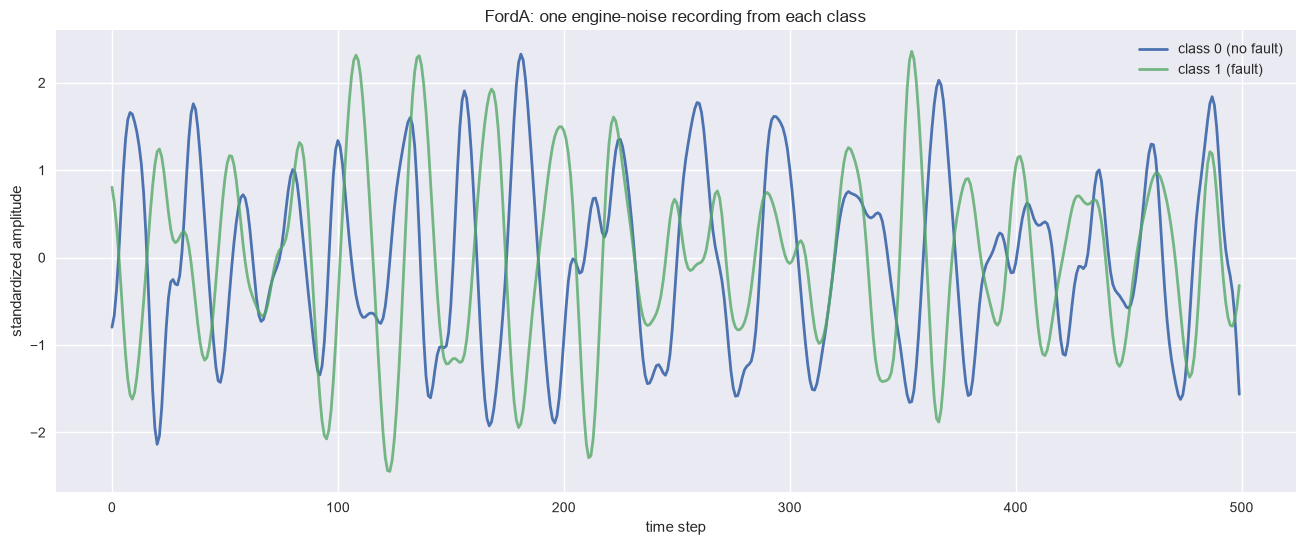

In [10]:
# one example of each class, drawn from the training set
example_0 = X_train[y_train == 0][0, :, 0]
example_1 = X_train[y_train == 1][0, :, 0]

plt.plot(example_0, linewidth=2, label='class 0 (no fault)')
plt.plot(example_1, linewidth=2, alpha=0.8, label='class 1 (fault)')
plt.title('FordA: one engine-noise recording from each class')
plt.xlabel('time step')
plt.ylabel('standardized amplitude')
plt.legend()
plt.show()

Before any modeling we look at the raw data - always. The boolean-mask indexing `X_train[y_train == 0]` selects all class-0 examples, `[0, :, 0]` takes the first one and drops the channel axis, and `Series`-style `plt.plot` overlays the two recordings.

The plot is deliberately humbling: to the naked eye, both classes are equally noisy, oscillating squiggles. There is no visible level shift, no obvious spike, no seasonal pattern - the class difference lives somewhere in the *texture* of the oscillations (the literature suggests fault signatures in the frequency content of the noise). This is exactly the kind of problem where learned features earn their keep, and where the question "how many labels do we need to learn those features?" - the question of this notebook - becomes economically interesting.

In [11]:
# hide 95% of the training labels
mask_lab = make_labeled_split(y_train, CFG.label_fraction, CFG.SEED)

X_lab, y_lab = X_train[mask_lab], y_train[mask_lab]     # the 5% we may use
X_unlab = X_train[~mask_lab]                            # the 95% without labels
y_unlab_secret = y_train[~mask_lab]                     # kept ONLY to audit pseudo-labels

print(f'labeled subset:   {X_lab.shape[0]} series, class counts {np.bincount(y_lab)}')
print(f'unlabeled pool:   {X_unlab.shape[0]} series')

labeled subset:   180 series, class counts [90 90]
unlabeled pool:   3421 series


Here the experiment takes shape. From the 3,601 training series, `make_labeled_split` marks a stratified 5% - **180 examples, 90 per class** - as *labeled*; the tilde in `X_train[~mask_lab]` (boolean NOT) collects the remaining 3,421 series into the unlabeled pool.

The variable name `y_unlab_secret` is a small honesty device. In a real project these labels would simply not exist. In our simulation they do exist, and we will use them for exactly one purpose: *auditing* - measuring, after the fact, how many of the labels a model assigns to the unlabeled pool are actually correct. No training step will ever touch them; keeping them in a separately named variable makes any accidental use easy to spot in code review.

Every method in the rest of the notebook plays by the same rules: **you may use all 3,601 raw series, but only 180 labels.** The differences lie in what each method does with the unlabeled 95%: ignore it (the baselines), learn representations from it (self-supervised), or label it itself (semi-supervised).

# Baselines: how far do labels alone take us?

In [12]:
# 1-nearest-neighbour on the raw series - the classic baseline of the field
knn_full = KNeighborsClassifier(n_neighbors=1).fit(X_train[..., 0], y_train)
acc = float(knn_full.score(X_test[..., 0], y_test))
scores['1-NN (100% labels)'] = acc
print(f'1-NN, all labels:      {acc:.3f}')

knn_small = KNeighborsClassifier(n_neighbors=1).fit(X_lab[..., 0], y_lab)
acc = float(knn_small.score(X_test[..., 0], y_test))
scores['1-NN (5% labels)'] = acc
print(f'1-NN, 5% of labels:    {acc:.3f}')

1-NN, all labels:      0.665
1-NN, 5% of labels:    0.585


Before touching a neural network, a rule this series shares with the wider literature: **always run an embarrassingly simple baseline first.** Time series classification has a famous one - the **1-nearest-neighbour classifier**: to classify a new series, find the single most similar training series (here by plain Euclidean distance over the 500 raw values, hence the `[..., 0]` that flattens away the channel axis) and copy its label. It has no parameters to train - `fit` just memorizes the data - yet on the UCR benchmarks 1-NN (especially with the fancier DTW distance) held its own against decades of more sophisticated methods, and its modern descendants (ROCKET, MiniRocket) remain near state-of-the-art. Any deep learning result that cannot beat 1-NN is a result about wasted electricity.

With all labels, 1-NN reaches **66.5%** on the test set - well above the 50% coin flip, and a free lunch given zero training cost. With only the 5% labeled subset to memorize it drops to **58.5%**: fewer stored neighbours means the nearest one is farther away and less often of the right class. These two numbers frame everything that follows - they are what "no learning at all" buys at each label budget.

In [13]:
# the supervised ceiling: our CNN trained on ALL 3601 labels
model_full = fit_classifier(X_train, y_train, CFG.sup_epochs, CFG.batch_size)
acc = test_accuracy(model_full, 'supervised CNN (100% labels)')
print(f'supervised CNN, all labels: {acc:.3f}')

supervised CNN, all labels: 0.932


Now the convolutional network, trained the way everyone wishes they could train - on the *complete* labeled training set. `fit_classifier` builds a fresh encoder-plus-softmax classifier and runs 40 epochs of Adam at the default learning rate.

The result, **93.2%**, is our **supervised ceiling**: the accuracy this particular architecture achieves when labels are no object. (The published state of the art on FordA is a few points higher still, using bigger networks and hundreds of epochs - our modest three-block CNN trained for 40 epochs is deliberately sized for a notebook that trains a dozen models, not for leaderboard chasing.) The ceiling already justifies deep learning on this problem: the CNN beats 1-NN by more than twenty-five accuracy points, because learned convolutional filters can pick up the discriminative texture that raw pointwise distances smear away.

Every self- and semi-supervised method below will land somewhere between the floor we are about to establish and this ceiling. The interesting question is never "can SSL beat the ceiling" (it cannot - it uses strictly less information) but "how much of the gap can it close".

In [14]:
# the label-scarce reality: the SAME architecture, but only 180 labels
model_small = fit_classifier(X_lab, y_lab, CFG.small_epochs, CFG.small_batch)
acc = test_accuracy(model_small, 'supervised CNN (5% labels)')
print(f'supervised CNN, 5% of labels: {acc:.3f}')

supervised CNN, 5% of labels: 0.799


Same architecture, same optimizer - but only the 180 labeled examples to learn from, and `CFG.small_epochs = 100` epochs to squeeze what it can out of them. The result: **79.9%**, a drop of about 13 accuracy points from the full-label ceiling.

Two things are worth being precise about. First, the mechanism of the drop: our CNN has roughly 26,000 trainable parameters against 180 training examples - over a hundred parameters per example - so it can (and does) drive its training loss toward zero by part-learning, part-*memorizing* the labeled set. The features it finds this way are real but incomplete: 180 recordings simply do not exhibit the full variety of fault signatures, and the model **overfits** to the sample it saw. Second, an experimental-design point hiding in that innocent `small_epochs`: at batch 32, one hundred epochs over 180 examples is only ~600 gradient steps - about half of what the full-data model got. Cut this small model's budget to a "fair-looking" 40 epochs and it lands near chance, making every method that follows look miraculous. Undertrained baselines are one of the quiet ways label-efficient learning papers flatter themselves; we give the baseline its full convergence and let the gap be what it is.

A 13-point gap is still a serious problem - in a fault-detection setting it is the difference between a deployable detector and a liability. The remedies this notebook is about attack it from an unusual side: they observe that we are drowning in *unlabeled* signal, and that a model which first learns what engine noise *looks like* in general should need far fewer labels to learn what *faulty* engine noise looks like. That is the bet; the rest of the notebook tests it.

# Self-supervised learning

The self-supervised recipe has two acts. **Act one - pretext training:** invent a task that needs no labels because the data itself provides the answer, and train the encoder on the full unlabeled pool. **Act two - transfer:** take the pretrained encoder, attach a small classification head, and use the precious 180 labels only for that last step.

The literature sorts pretext tasks into three families. **Generative** methods hide part of the input and reconstruct it (masked modeling, denoising autoencoders, forecasting-as-pretext). **Contrastive** methods create multiple views of each series and train the encoder to recognize which views belong together. **Adversarial** methods train a generator against a discriminator, GAN-style. We will implement one representative of each of the first two families - masked reconstruction, then contrastive learning - which are the workhorses of the field; adversarial pretraining is rarer in practice and we leave it as a pointer to the literature.

## Pretext task 1: masked reconstruction

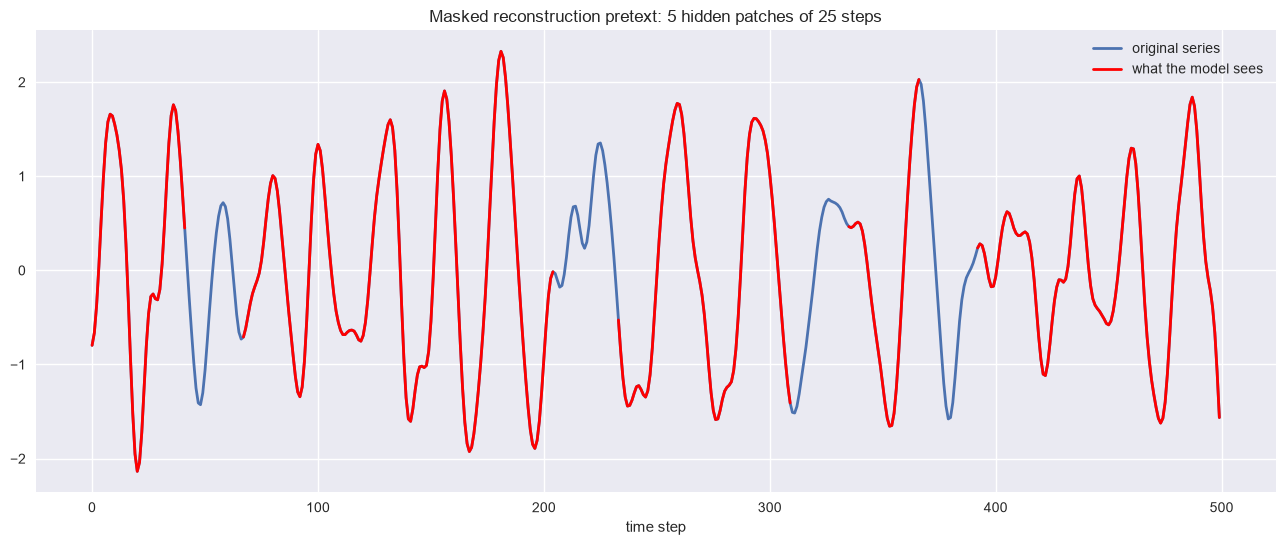

In [15]:
PATCH_LEN = 25    # length of each hidden stretch
N_PATCHES = 5     # stretches hidden per series (~25% of all 500 steps)

# demonstrate the pretext task on one training series
rng_demo = np.random.default_rng(CFG.SEED)
demo_masked, demo_mask = mask_patches(X_train[:1], rng_demo,
                                      patch_len=PATCH_LEN, n_patches=N_PATCHES)

plt.plot(X_train[0, :, 0], linewidth=2, label='original series')
plt.plot(np.where(demo_mask[0, :, 0], np.nan, demo_masked[0, :, 0]),
         color='red', linewidth=2, label='what the model sees')
plt.title(f'Masked reconstruction pretext: {N_PATCHES} hidden patches of {PATCH_LEN} steps')
plt.xlabel('time step')
plt.legend()
plt.show()

The first pretext task is **masked reconstruction** - the time series cousin of how BERT learns language (hide words, predict them) and how masked autoencoders learn vision (hide image patches, repaint them). The supervision is free: the "label" for a hidden stretch is simply the original signal, which we had all along.

The two constants follow the convention of SCREAMING_SNAKE_CASE for values defined just above first use. `PATCH_LEN = 25` and `N_PATCHES = 5` hide five 25-step stretches per series - up to 125 of 500 steps (25%) when patches do not overlap, in line with the masking ratios used by PatchTST and friends.

The plot shows the model's-eye view: the blue curve is the complete series, the red curve is what actually enters the network, with `np.where(mask, np.nan, ...)` exploiting the fact that matplotlib simply leaves a gap wherever it meets a `NaN` - so the hidden patches appear as literal holes. To fill a 25-step hole in engine noise the network cannot interpolate; it must have absorbed, from the visible context, what this kind of oscillation locally looks like. That knowledge - not the reconstructions themselves - is what we are after: it lives in the encoder weights, and it was acquired without a single label.

In [16]:
# encoder (time axis preserved) + a per-timestep linear head = masked autoencoder
keras.utils.set_random_seed(CFG.SEED)
rng_mask = np.random.default_rng(CFG.SEED)

with keras.device(DEVICE):
    encoder_masked = build_encoder(pooled=False)
    inp = keras.Input(shape=(SEQ_LEN, 1))
    h = encoder_masked(inp)
    out = layers.Dense(1)(h)          # one reconstructed value per time step
    masked_ae = keras.Model(inp, out)
    masked_ae.compile(optimizer='adam', loss='mse')

    X_masked, _ = mask_patches(X_train, rng_mask,
                               patch_len=PATCH_LEN, n_patches=N_PATCHES)
    history = masked_ae.fit(X_masked, X_train,
                            epochs=CFG.pretrain_epochs,
                            batch_size=CFG.batch_size, verbose=0)

print(f'reconstruction MSE after pretraining: {history.history["loss"][-1]:.4f}')

reconstruction MSE after pretraining: 0.0923


The masked autoencoder is our shared backbone with `pooled=False` - so the time axis survives and the encoder emits a 64-dimensional feature vector *at every time step* - topped by a **`Dense(1)`** head. A `Dense` layer applied to a 3-D tensor acts independently on each time step, so this head is a per-timestep linear readout: at every position it converts the 64 features into one reconstructed signal value. (A `Conv1D(1, ...)` layer would be the more conventional choice here, but a single-output-channel `Conv1D` trips a Metal-framework assertion in the backward pass on MPS devices at the time of writing - a reminder that GPU backends are software too. The `Dense` head is mathematically equivalent to a width-1 convolution and sidesteps the bug.)

The training call is where the pretext task becomes concrete: `masked_ae.fit(X_masked, X_train, ...)` - the *masked* series as input, the *original* series as target, mean-squared error as the loss. Note that the model reconstructs all 500 steps, and the loss covers visible positions too; at visible positions the task is trivial (copy the input), so the gradient signal that actually shapes the encoder comes overwhelmingly from the hidden patches. Purist implementations compute the loss only over masked positions - with our masking ratio the difference is mostly a constant factor on the loss scale.

Notice what this cell does **not** use: `y_train`. All 3,601 series participate, labeled or not. This is the "act one" of self-supervision - the encoder is learning the structure of engine noise from everything we have.

MSE at hidden positions only (test set): 0.391


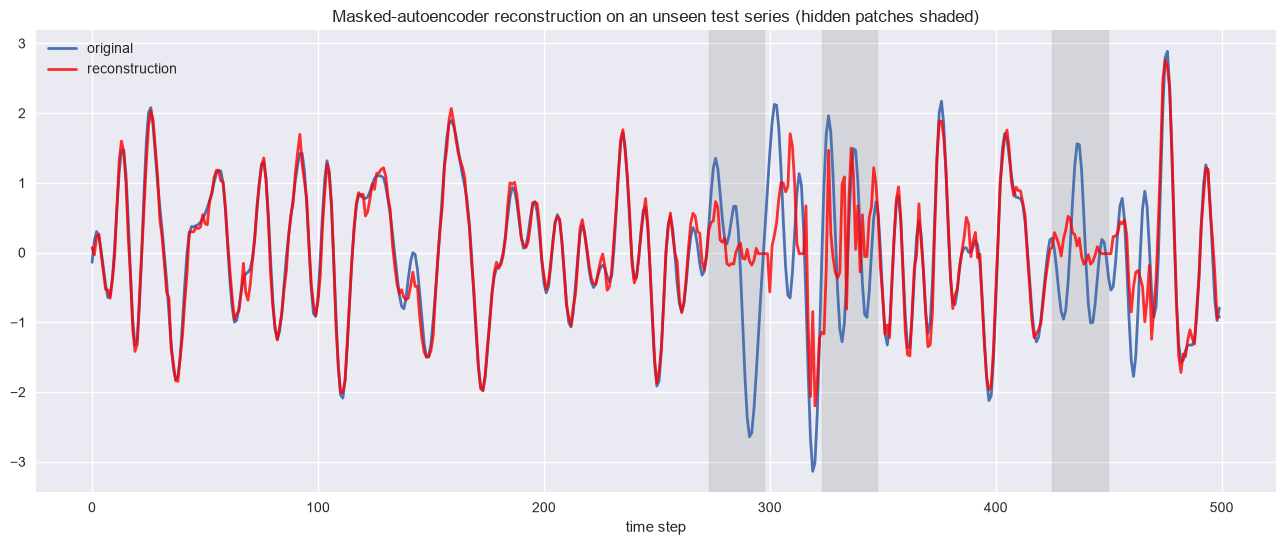

In [17]:
# how well does it fill the holes? (on TEST series it never saw)
rng_recon = np.random.default_rng(7)
X_test_masked, test_mask = mask_patches(X_test, rng_recon,
                                        patch_len=PATCH_LEN, n_patches=N_PATCHES)
recon = masked_ae.predict(X_test_masked, batch_size=256, verbose=0)

mse_hidden = float(np.mean((recon[test_mask] - X_test[test_mask]) ** 2))
print(f'MSE at hidden positions only (test set): {mse_hidden:.3f}')

SHOW = 0   # which test series to display
plt.plot(X_test[SHOW, :, 0], linewidth=2, label='original')
plt.plot(recon[SHOW, :, 0], color='red', linewidth=2, alpha=0.8, label='reconstruction')
for s in np.where(np.diff(test_mask[SHOW, :, 0].astype(int)) == 1)[0]:
    plt.axvspan(s, s + PATCH_LEN, color='gray', alpha=0.2)
plt.title('Masked-autoencoder reconstruction on an unseen test series (hidden patches shaded)')
plt.xlabel('time step')
plt.legend()
plt.show()

Before trusting the encoder, we inspect what it learned - on *test* series, masked with a different random generator (`default_rng(7)`), so nothing here was seen during pretraining. The boolean mask lets us score the reconstruction **only at hidden positions**: MSE of **0.391**, against series with unit variance - so the model recovers a substantial share of the hidden signal's energy, but far from all of it.

The plot tells the same story graphically. Outside the patches the red reconstruction hugs the original almost perfectly, as it should: there the "task" is copying the visible input. Inside the shaded hidden patches (the `axvspan` loop finds where the mask switches on and shades `PATCH_LEN` steps from each onset), the reconstruction is visibly *damped* - it leans toward the local mean, recovering the entry and exit of each hole and a subdued version of the swings between, but not their full amplitude. This is not a bug: many continuations are consistent with the visible context, the MSE loss makes the model predict something like their *average*, and averaging over possibilities shrinks the oscillations.

An imperfect reconstruction is not a failure - we never wanted a signal-restoration tool. The question that matters is whether the *features* the encoder built in order to fill holes are also features that separate faulty engines from healthy ones. That is what the next two cells measure.

In [18]:
def linear_probe(encoder, name=None):
    """Freeze the encoder; train only a logistic regression on the 180 labels."""
    with keras.device(DEVICE):
        f_lab = encoder.predict(X_lab, batch_size=256, verbose=0)
        f_test = encoder.predict(X_test, batch_size=256, verbose=0)
    if f_lab.ndim == 3:                       # sequence output -> average over time
        f_lab, f_test = f_lab.mean(axis=1), f_test.mean(axis=1)
    clf = LogisticRegression(max_iter=2000).fit(f_lab, y_lab)
    acc = float(clf.score(f_test, y_test))
    if name is not None:
        scores[name] = acc
    return acc

acc = linear_probe(encoder_masked, 'masked AE + linear probe (5%)')
print(f'masked AE, linear probe on 5% labels: {acc:.3f}')

masked AE, linear probe on 5% labels: 0.724


The **linear probe** is the field's standard first exam for a learned representation, so we define it as a reusable helper (two more encoders will take the same exam later). The protocol: run every series through the *frozen* encoder to get its 64-dimensional embedding (for this sequence-shaped encoder, `.mean(axis=1)` averages features over time - the NumPy equivalent of the `GlobalAveragePooling1D` step), then train nothing but a **logistic regression** - a single linear layer - on the 180 labeled embeddings.

The logic of the protocol: a linear model has no feature-learning power of its own, so its accuracy measures how **linearly separable** the classes already are in the embedding space - which is precisely the encoder's contribution. And because logistic regression fits ~65 parameters rather than 26,000, the 180 labels are suddenly a reasonable amount of data; the overfitting catastrophe of the supervised baseline cannot recur here.

The verdict: **72.4%** - respectable for 65 fitted parameters, far above the coin flip, but *below* the 79.9% of the properly-trained supervised CNN at the same label budget. Reconstruction-driven features carry real class-relevant information, but frozen, they are not competitive on their own. Two chances at redemption remain: the second evaluation protocol (let the features adapt), and then a different pretext task altogether.

In [19]:
# fine-tuning: same pretrained encoder, but ALL weights may adapt (small lr)
model_ft = fit_classifier(X_lab, y_lab, CFG.finetune_epochs, CFG.small_batch,
                          encoder=copy_encoder(encoder_masked, pooled=False),
                          lr=1e-4)
acc = test_accuracy(model_ft, 'masked AE + fine-tune (5%)')
print(f'masked AE, fine-tuned on 5% labels: {acc:.3f}')

masked AE, fine-tuned on 5% labels: 0.777


The second exam is **fine-tuning**: instead of freezing the encoder, we put a softmax head on a *copy* of it (the `copy_encoder` helper - remember that fine-tuning mutates weights, and the original pretrained encoder must stay clean for later cells) and let *all* weights train on the 180 labels. Because this encoder was built with `pooled=False` for the reconstruction task, it emits sequence-shaped features - this is exactly the case the `len(h.shape) == 3` branch of `build_classifier` was written for: a `GlobalAveragePooling1D` slots in between the pretrained encoder and the new head, exactly as in the standard classifier.

The learning rate drops to **`1e-4`**, a tenth of the default. This is the standard fine-tuning precaution: large steps would let the 180 labels' noisy gradients bulldoze the carefully pretrained weights within a few batches ("catastrophic forgetting"), reverting us to the from-scratch regime. Small steps keep the solution in the neighbourhood of the pretrained one, using the labels only to *nudge* features toward class-relevance.

Fine-tuning lands at **77.7%** - above the linear probe, as is typical (letting features adapt beats bolting a linear readout onto frozen ones), but here is the honest headline: *still not above the 79.9% from-scratch baseline.* On this dataset, masked-reconstruction pretraining does not pay for classification. That is a legitimate, literature-consistent result rather than a failed experiment: reconstruction rewards the encoder for retaining *everything* about the signal - class-relevant or not - which makes it the pretext of choice for forecasting and imputation, but gives it no particular reason to organize instances into separable classes. Hold that thought through the next section, where a pretext task built on *comparison* rather than reconstruction meets the same exams.

In [20]:
# the control experiment: pretrain with POINTWISE masking instead of patches
keras.utils.set_random_seed(CFG.SEED)
rng_mask_pt = np.random.default_rng(CFG.SEED)

with keras.device(DEVICE):
    encoder_pointwise = build_encoder(pooled=False)
    inp = keras.Input(shape=(SEQ_LEN, 1))
    out = layers.Dense(1)(encoder_pointwise(inp))
    pointwise_ae = keras.Model(inp, out)
    pointwise_ae.compile(optimizer='adam', loss='mse')
    X_masked_pt, _ = mask_patches(X_train, rng_mask_pt, pointwise=True)
    pointwise_ae.fit(X_masked_pt, X_train, epochs=CFG.pretrain_epochs,
                     batch_size=CFG.batch_size, verbose=0)

acc = linear_probe(encoder_pointwise, 'pointwise-mask AE + probe (5%)')
print(f'pointwise masking, linear probe: {acc:.3f}')

pointwise masking, linear probe: 0.709


A claim from the literature deserves a controlled test rather than a citation: *point-level masking is too easy - isolated holes can be filled by interpolation, so the encoder learns little.* This cell repeats the pretraining identically except for one flag, `pointwise=True`: the same ~25% of steps are hidden, but as scattered single points instead of 25-step patches.

The linear probe answers: **70.9%** with pointwise masking versus **72.4%** with patch masking. The direction matches the claim - patches beat points - though on FordA the margin is modest rather than dramatic. The likely reason: engine noise oscillates so fast that even an isolated missing point is not trivially interpolable, so pointwise masking is less degenerate here than on smooth signals. On slowly-varying series (temperatures, demand curves, vital signs) the literature finds the gap far wider - which is why patch masking is the safe default.

The deeper lesson generalizes beyond masking: in self-supervised learning, **the difficulty of the pretext task is a design parameter**. Make the task too easy and the encoder can solve it with shortcuts that transfer nothing; make it too hard (mask 90% of a chaotic signal) and the task degenerates into guessing. The patch length and masking ratio here sit in the band the literature has converged on for exactly this reason.

## Pretext task 2: contrastive learning

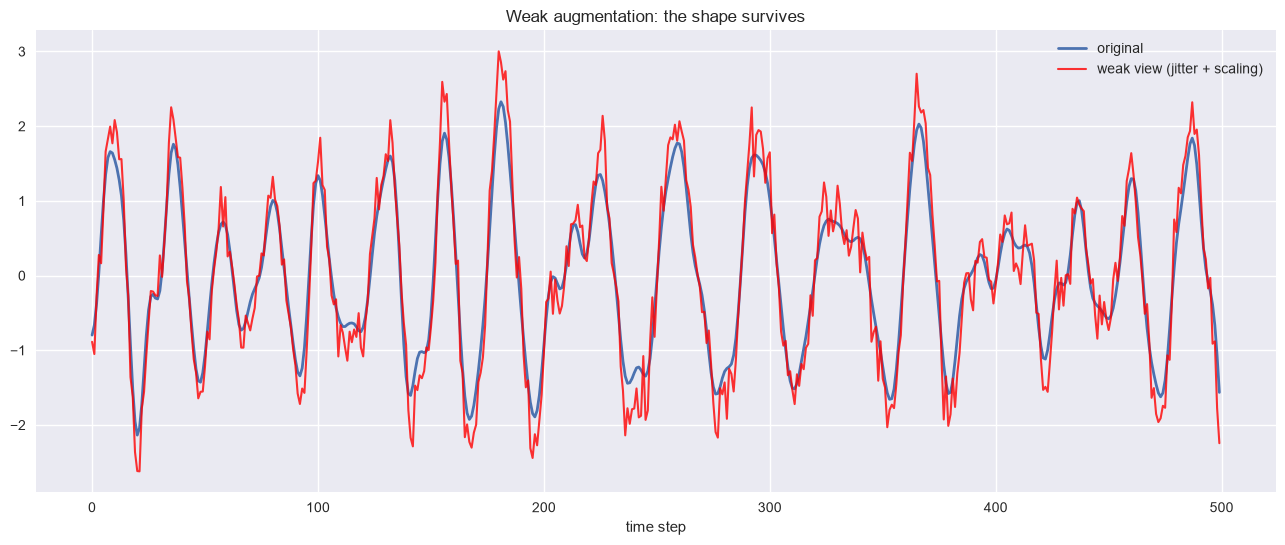

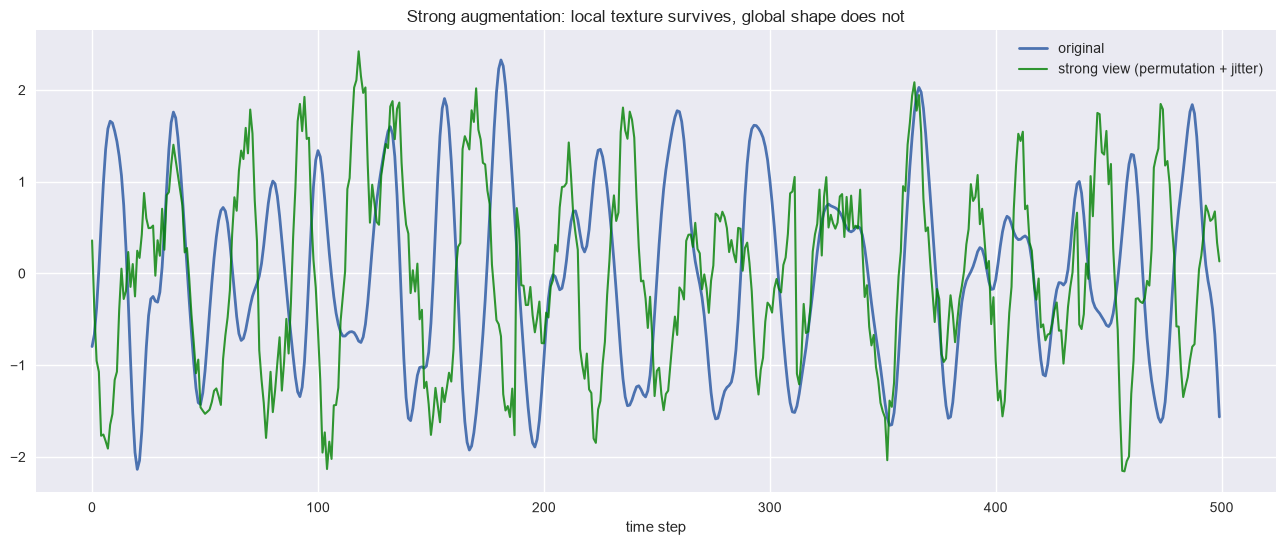

In [21]:
# what the two augmentation strengths do to a series
rng_views = np.random.default_rng(CFG.SEED)
series = X_train[:1]

plt.plot(series[0, :, 0], linewidth=2, label='original')
plt.plot(weak_aug(series, rng_views)[0, :, 0], color='red', linewidth=1.5,
         alpha=0.8, label='weak view (jitter + scaling)')
plt.title('Weak augmentation: the shape survives')
plt.xlabel('time step')
plt.legend()
plt.show()

plt.plot(series[0, :, 0], linewidth=2, label='original')
plt.plot(strong_aug(series, rng_views)[0, :, 0], color='green', linewidth=1.5,
         alpha=0.8, label='strong view (permutation + jitter)')
plt.title('Strong augmentation: local texture survives, global shape does not')
plt.xlabel('time step')
plt.legend()
plt.show()

The second pretext task needs its raw material demonstrated first. **Contrastive learning** trains an encoder by comparison rather than reconstruction: create two randomly augmented *views* of each series, and demand that the encoder map views of the *same* series close together (a **positive pair**) while views of *different* series land far apart (**negative pairs**). No pixel-level target, no labels - the supervisory signal is pure identity: "these two came from the same recording."

The two figures (sequential, per the house style) show the augmentations from the Utils section acting on one training series. The weak view is visually almost the original - a slight thickening from jitter, a slight amplitude change from scaling. The strong view is a different creature: its 8 segments are the original's segments, each locally intact, but shuffled into a new order - zoom into any 60-step stretch and it looks like plausible engine noise; zoom out and the global shape is gone.

For the contrastive pretraining below we will pair two *weak* views: the encoder should consider a recording "the same engine noise" regardless of measurement noise and gain. The strong augmentation's day comes later, in the FixMatch section, where the weak/strong asymmetry is the whole trick.

In [22]:
def nt_xent_loss(temperature=0.1):
    """NT-Xent (InfoNCE) contrastive loss.

    y_pred carries the two views' projections side by side: [z1 | z2], (B, 2D).
    Views of the same series are positives; everything else in the batch is negative.
    """
    def loss(y_true, y_pred):
        d = ops.shape(y_pred)[-1] // 2
        z1 = ops.normalize(y_pred[:, :d], axis=-1)
        z2 = ops.normalize(y_pred[:, d:], axis=-1)
        z = ops.concatenate([z1, z2], axis=0)                 # (2B, D)
        sim = ops.matmul(z, ops.transpose(z)) / temperature   # (2B, 2B) similarities
        b = ops.shape(z1)[0]
        n = 2 * b
        sim = sim - ops.eye(n) * 1e9                          # forbid matching yourself
        positive_idx = ops.concatenate([ops.arange(b, n), ops.arange(0, b)], axis=0)
        return ops.categorical_crossentropy(ops.one_hot(positive_idx, n),
                                            sim, from_logits=True)
    return loss

The engine of contrastive learning is the **NT-Xent loss** (normalized temperature-scaled cross-entropy, also known as InfoNCE), written here in `keras.ops` so it runs on any backend and stays differentiable. In formula form, for an anchor embedding $z_i$ with positive partner $z_j$ among $2B$ candidates: $\ell_i = -\log \frac{\exp(\mathrm{sim}(z_i, z_j)/\tau)}{\sum_{k \neq i} \exp(\mathrm{sim}(z_i, z_k)/\tau)}$ - the cross-entropy of picking your partner out of the crowd.

Walking through the code: the two views' projections arrive glued side by side in `y_pred` (a packaging trick explained at the next cell), are split and **L2-normalized** so that the matrix product `z @ z.T` becomes a matrix of *cosine similarities* between every pair of the $2B$ embeddings. Division by the **temperature** `τ = 0.1` sharpens the distribution - low temperature makes the softmax concentrate on the hardest (most similar) negatives, which is where the learning signal is. Subtracting `1e9` on the diagonal removes the degenerate "every embedding is most similar to itself" solution. The `positive_idx` line encodes who everyone's partner is: view 1 of series $i$ sits at row $i$, its positive at row $B+i$, and vice versa - hence a target index vector `[B..2B-1, 0..B-1]`. Feeding those targets to `categorical_crossentropy(..., from_logits=True)` turns each row of the similarity matrix into a $2B-1$-way classification: *find your partner among the crowd*.

That framing explains why contrastive learning suits classification so well: the task literally shapes the geometry of the embedding space, pulling related samples together and pushing unrelated ones apart - which is the geometry a downstream linear classifier needs.

In [23]:
# siamese pretraining: two augmented views through ONE shared encoder
keras.utils.set_random_seed(CFG.SEED)
rng_con = np.random.default_rng(CFG.SEED)

with keras.device(DEVICE):
    encoder_con = build_encoder(pooled=True)
    projection = keras.Sequential([layers.Dense(64, activation='relu'),
                                   layers.Dense(32)])
    view_a = keras.Input(shape=(SEQ_LEN, 1))
    view_b = keras.Input(shape=(SEQ_LEN, 1))
    z_a = projection(encoder_con(view_a))
    z_b = projection(encoder_con(view_b))
    contrastive_model = keras.Model([view_a, view_b],
                                    ops.concatenate([z_a, z_b], axis=-1))
    contrastive_model.compile(optimizer='adam', loss=nt_xent_loss())

    dummy_target = np.zeros(len(X_train))       # NT-Xent ignores y_true entirely
    for epoch in range(CFG.pretrain_epochs):
        V1 = weak_aug(X_train, rng_con)         # fresh random views EVERY epoch
        V2 = weak_aug(X_train, rng_con)
        contrastive_model.fit([V1, V2], dummy_target, epochs=1,
                              batch_size=CFG.batch_size, verbose=0)

contrastive_weights = encoder_con.get_weights()   # snapshot for later reuse
print('contrastive pretraining finished')

contrastive pretraining finished


The pretraining model is **siamese**: the two `keras.Input` branches pass through the *same* `encoder_con` and `projection` objects, so both views share every weight - calling a Keras model twice reuses it, it does not copy it. The **projection head** (Dense 64 → Dense 32) is a standard contrastive-learning accessory: the contrastive loss is applied to its output, but *only the encoder underneath is kept* afterwards. The head absorbs the last, most task-specific bit of the invariance pressure, leaving the encoder's features more general.

Two implementation idioms are worth stealing. First, the **dummy-target trick**: Keras insists every compiled loss receive a `y_true`, but NT-Xent needs none - the "labels" are implicit in the batch positions. So we hand `.fit` an array of zeros that the loss function never reads, and package both views' projections into one output tensor (`ops.concatenate`) so the loss can see them together. Second, the training loop generates **fresh augmented views every epoch** rather than augmenting once up front: seeing a different random distortion of each series each time is precisely what forces the encoder to abstract away from the noise instead of memorizing one particular distortion. That is also why `.fit` is called for one epoch inside a Python loop instead of once with `epochs=30`.

The final line snapshots the pretrained weights with `get_weights()` - later sections (fine-tuning at several label budgets) will each want to start from this exact state, and the snapshot spares us re-running pretraining.

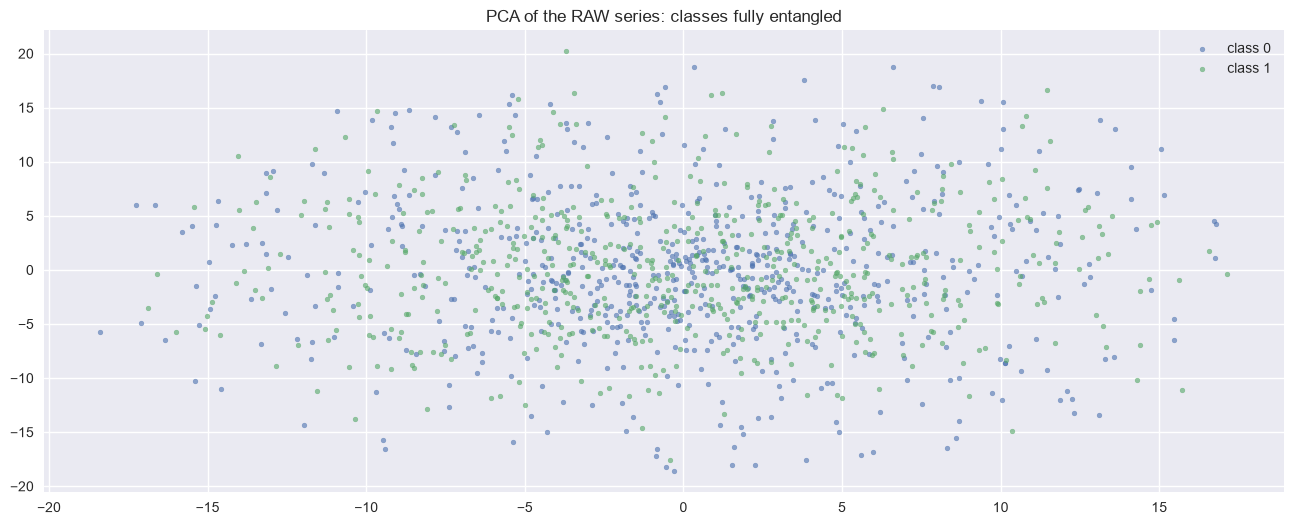

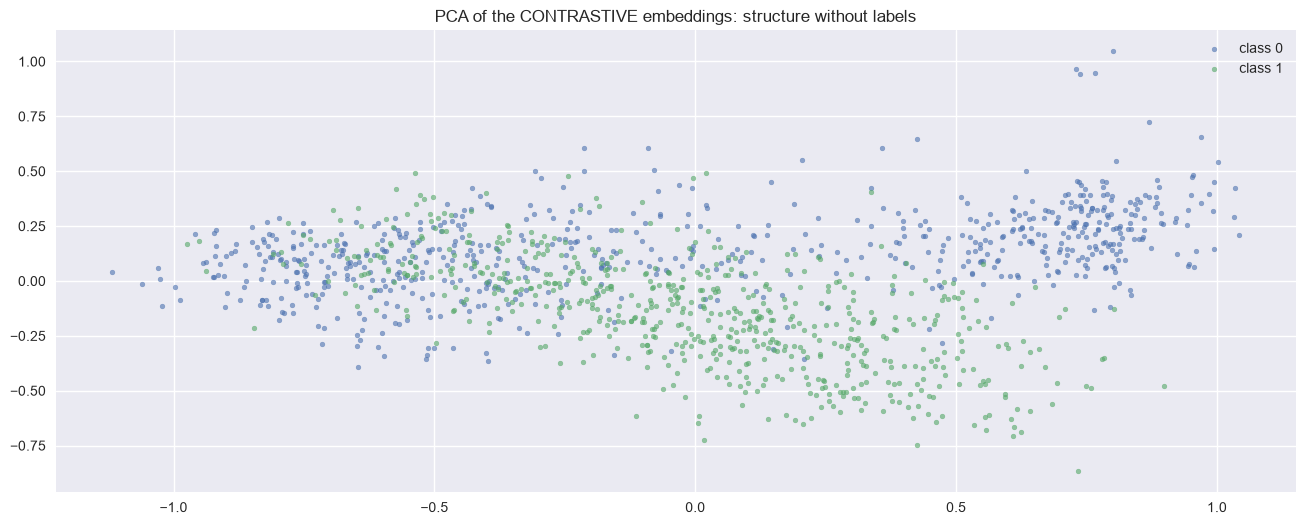

In [24]:
# what did it learn? PCA of the TEST-set embeddings, colored by the TRUE labels
with keras.device(DEVICE):
    emb_test = encoder_con.predict(X_test, batch_size=256, verbose=0)

flat_2d = PCA(n_components=2).fit_transform(X_test[..., 0])   # raw series, for contrast
emb_2d = PCA(n_components=2).fit_transform(emb_test)

plt.scatter(flat_2d[y_test == 0, 0], flat_2d[y_test == 0, 1], s=12, alpha=0.6, label='class 0')
plt.scatter(flat_2d[y_test == 1, 0], flat_2d[y_test == 1, 1], s=12, alpha=0.6, label='class 1')
plt.title('PCA of the RAW series: classes fully entangled')
plt.legend()
plt.show()

plt.scatter(emb_2d[y_test == 0, 0], emb_2d[y_test == 0, 1], s=12, alpha=0.6, label='class 0')
plt.scatter(emb_2d[y_test == 1, 0], emb_2d[y_test == 1, 1], s=12, alpha=0.6, label='class 1')
plt.title('PCA of the CONTRASTIVE embeddings: structure without labels')
plt.legend()
plt.show()

A representation is worth inspecting before it is scored. Both plots show test-set data projected to two dimensions by **PCA** (principal component analysis - the linear projection retaining the most variance) and *colored by the true labels, which the encoder has never seen*.

The first plot is the control: PCA applied to the raw 500-step series. The two classes form one undifferentiated cloud - in raw-signal space, faulty and healthy engines are not linearly distinguishable, which is the geometric restatement of why 1-NN struggles and why a linear model on raw values would fail.

The second plot is the same test set after the contrastive encoder. The two classes now occupy visibly different regions of the plane - one concentrated toward the lower band of the cloud, the other toward the upper and right - with a contested frontier where they still mix. And this is only a 2-D shadow of the 64-dimensional embedding space; the linear probe below will find considerably cleaner separation than the eye can see here. The encoder was never told that classes exist; it was only asked to make each recording recognizable across noise and gain changes. But the features that make recordings mutually distinguishable - their oscillation texture - turn out to be correlated with the fault condition, so class structure *emerges as a by-product*. This is the quiet magic of self-supervised learning, and also its limitation: the structure emerges only insofar as the pretext task's notion of similarity aligns with the downstream task's. Nothing guarantees it in general; here, it happens to.

In [25]:
# the same two exams as before: linear probe, then fine-tune
acc = linear_probe(encoder_con, 'contrastive + linear probe (5%)')
print(f'contrastive, linear probe on 5% labels: {acc:.3f}')

model_con_ft = fit_classifier(X_lab, y_lab, CFG.finetune_epochs, CFG.small_batch,
                              encoder=copy_encoder(encoder_con), lr=1e-4)
acc = test_accuracy(model_con_ft, 'contrastive + fine-tune (5%)')
print(f'contrastive, fine-tuned on 5% labels: {acc:.3f}')

contrastive, linear probe on 5% labels: 0.913


contrastive, fine-tuned on 5% labels: 0.923


The contrastive encoder takes the same two exams the masked autoencoder took, and the results are of a different order: probe **91.3%**, fine-tuned **92.3%** - versus 72.4% and 77.7% for the masked AE. Pause on what the fine-tuned number means: with 5% of the labels, the contrastive model lands within roughly one accuracy point of the **full-label ceiling** (93.2%), closing nearly the entire 13-point gap that label scarcity had opened. Even the frozen encoder plus a 65-parameter logistic regression beats the from-scratch CNN (79.9%) by a wide margin.

The direction of this result is one of the most consistent findings in the literature: **contrastive pretraining tends to win at classification, masked/generative pretraining at forecasting and imputation.** The mechanism is visible from what each loss optimizes. NT-Xent directly sculpts an embedding geometry - same-thing-together, different-things-apart - which is one linear cut away from a classifier. Reconstruction losses reward retaining *everything* about the signal, class-relevant or not, in features spread across time; excellent raw material for predicting the signal's continuation, but with no pressure to organize instances into separable clusters.

The flip side deserves equal emphasis: the contrastive result leans on our augmentations being *semantically safe* - jitter and scaling must not change what class a recording belongs to. For engine noise that assumption is sound. For your dataset it might not be, and a wrong augmentation menu silently teaches the encoder to ignore the signal that matters. The masked-reconstruction pretext needs no such domain judgment - a genuine advantage in unfamiliar domains, and part of why both families coexist in practice.

# Semi-supervised learning

Self-supervised pretraining never looked at a label until the final head. **Semi-supervised** methods take the opposite tack: use the labeled and unlabeled data *simultaneously*, inside one training process. The three classic strategies, in increasing order of subtlety: **pseudo-labeling** (let the model label the unlabeled pool itself and retrain on its own guesses), **consistency regularization** (require stable predictions under perturbation - we implement its modern FixMatch form), and **joint multi-task training** (bolt an unsupervised auxiliary objective onto the supervised loss so both learn one shared encoder). We take them in that order.

## Pseudo-labeling (self-training)

In [26]:
# the weak model from the baseline section labels the pool it was never trained on
pool_probs = model_small.predict(X_unlab, batch_size=256, verbose=0)
pool_conf = pool_probs.max(axis=1)          # confidence = probability of the argmax class
pseudo_labels = pool_probs.argmax(axis=1)

accepted = pool_conf >= CFG.conf_threshold
audit_acc = float((pseudo_labels[accepted] == y_unlab_secret[accepted]).mean())

print(f'pool size {len(X_unlab)}, accepted at conf>={CFG.conf_threshold}: {accepted.sum()}')
print(f'class balance of accepted pseudo-labels: {np.bincount(pseudo_labels[accepted])}')
print(f'audit: accepted pseudo-labels are {audit_acc:.1%} correct '
      f'(vs {float((pseudo_labels == y_unlab_secret).mean()):.1%} for ALL pseudo-labels)')

pool size 3421, accepted at conf>=0.95: 1788
class balance of accepted pseudo-labels: [ 701 1087]
audit: accepted pseudo-labels are 97.5% correct (vs 78.6% for ALL pseudo-labels)


Pseudo-labeling starts from an almost impertinent idea: our weak 5%-label model (79.9% accurate) will *itself* annotate the 3,421 unlabeled series, and we will train on its annotations as if they were truth. Stated baldly this sounds like a perpetual-motion machine - how can a model learn from its own guesses? The answer is the **confidence filter**: we keep only predictions where the softmax probability of the winning class reaches `CFG.conf_threshold = 0.95`. Even a mediocre classifier is usually much better than its average on the examples it is *sure* about; by harvesting only those, we trade quantity for quality.

The audit line - our one sanctioned use of `y_unlab_secret` - shows the filter working: of the 1,788 accepted pseudo-labels, **97.5%** are correct, against 78.6% correctness across all pseudo-labels. In a real project this audit is impossible (that is the point of not having labels), which is why the confidence threshold is such a consequential hyperparameter: set it too low and you flood training with wrong labels, too high and you accept nothing. (One practical footnote: for the filter to work at all, the teacher must be *trained to convergence* - an undertrained network hedges every prediction near 0.5 and nothing clears the bar. Our 100-epoch teacher is confident where it should be.)

The class-balance line is a warning worth reading: the accepted set leans noticeably toward one class, because the teacher happens to be more *confident* about it - even though the pool itself is balanced. Confidence filtering silently reshapes the class distribution of your training data. And the residual errors in the accepted set are not benign noise, either - they are the model's *confident* mistakes, and retraining on them entrenches them. This failure mode has a name, **confirmation bias**; it is the standing danger of everything in the self-training family, and the next section will show it to us live.

In [27]:
STUDENT_EPOCHS = 80   # the combined set is mid-sized: more epochs than full-data
                      # training needs, fewer than the 180-example runs got

# retrain from scratch on real labels + accepted pseudo-labels
X_pseudo = np.concatenate([X_lab, X_unlab[accepted]])
y_pseudo = np.concatenate([y_lab, pseudo_labels[accepted]])

model_pl = fit_classifier(X_pseudo, y_pseudo, STUDENT_EPOCHS, CFG.batch_size)
acc = test_accuracy(model_pl, 'pseudo-labeling (5%)')
print(f'pseudo-labeling, one round: {acc:.3f} (teacher was {scores["supervised CNN (5% labels)"]:.3f})')

pseudo-labeling, one round: 0.892 (teacher was 0.799)


The harvest: `np.concatenate` welds the 180 genuinely labeled series to the 1,788 confidently pseudo-labeled ones, and a **fresh** model trains on the combined set (note `fit_classifier` builds from scratch - retraining the teacher on its own outputs risks compounding its quirks; a fresh student sees the pseudo-labels as ordinary data). The batch size steps up to 128 now that the training set is thousands strong, not 180.

The student scores **89.2%** - a jump of roughly nine accuracy points over its own teacher, without one new human label. The mechanism: although some pseudo-labels are wrong, the thousands of correct ones expose the student to a far broader sample of what each class looks like than 180 examples ever could, and the network's tendency to fit *systematic* patterns before *idiosyncratic* noise means the (mostly random) label errors hurt less than the extra coverage helps.

Worth pausing on: this simple loop - train, predict, filter by confidence, retrain - is arguably the highest benefit-to-effort technique in this notebook. It needs no new architecture, no custom loss, no augmentation design; any classifier that outputs probabilities can play. That is why self-training predates deep learning by decades and still anchors the semi-supervised toolbox.

## Consistency training, FixMatch-style - and confirmation bias, live

In [28]:
N_ROUNDS = 3

rng_fix = np.random.default_rng(CFG.SEED)
student = model_small                        # round 1 teacher = the 5%-label baseline
for rnd in range(N_ROUNDS):
    # 1. predict on WEAKLY augmented pool; filter by confidence
    probs = student.predict(weak_aug(X_unlab, rng_fix), batch_size=256, verbose=0)
    conf, pl = probs.max(axis=1), probs.argmax(axis=1)
    keep = conf >= CFG.conf_threshold
    # 2. fresh student: real labels + accepted pool series + their STRONG views
    X_round = np.concatenate([X_lab, X_unlab[keep], strong_aug(X_unlab[keep], rng_fix)])
    y_round = np.concatenate([y_lab, pl[keep], pl[keep]])
    student = fit_classifier(X_round, y_round, STUDENT_EPOCHS, CFG.batch_size)
    audit = float((pl[keep] == y_unlab_secret[keep]).mean()) if keep.sum() else np.nan
    print(f'round {rnd + 1}: accepted {keep.sum():4d} pseudo-labels '
          f'({audit:.1%} correct), test accuracy {test_accuracy(student):.3f}')

scores['FixMatch-style, 3 rounds (5%)'] = test_accuracy(student)

round 1: accepted 1320 pseudo-labels (91.9% correct), test accuracy 0.821


round 2: accepted 2721 pseudo-labels (64.3% correct), test accuracy 0.567


round 3: accepted 3375 pseudo-labels (52.0% correct), test accuracy 0.516


**FixMatch** distilled years of consistency-regularization research into one asymmetric rule, which this loop adapts to time series: *harvest pseudo-labels on the weak view, make the student honour them on the strong view.* Pseudo-labels come from weakly augmented series - jitter and scaling leave the class evident, so the predictions stay trustworthy. The student then trains on each accepted series *and* on its strongly augmented double, where segment shuffling has destroyed the global shape - so the same label must be fit both ways. That is a consistency requirement in disguise: whatever the model believes about a series, it must maintain under severe perturbation, which pushes it to find class evidence in the local texture that permutation preserves. The loop's second ingredient is **iteration**: each round's student becomes the next round's teacher, and the hope is a flywheel - better teacher → more confident predictions → more training data → better student.

The printed round log shows what actually happened, and it is the most instructive output in the notebook. Round 1 behaves: 1,320 accepted pseudo-labels, 91.9% of them correct, test accuracy 82.1% - ahead of the teacher's 79.9%. Then the flywheel spins *backwards*. By round 3, the student accepts 3,375 of the 3,421 pool series - but only 52.0% of those labels are correct, and test accuracy has collapsed to **51.6%**, barely above the coin flip. This is **confirmation bias** compounding in real time: a student trained partly on distorted, permuted copies becomes *confidently wrong* on part of the pool; the threshold happily accepts its confident mistakes; the next student learns them as truth and mints new ones. Acceptance rising while accuracy falls is the exact signature to memorize - in the audit columns above you can watch quantity go up as quality drains away.

Why did our plain pseudo-labeling survive what FixMatch-style iteration did not? One round, taken from a *cleanly trained, well-calibrated* teacher, harvested only good labels and stopped. The iterated loop kept re-harvesting from students whose training data - full of shuffled strong views - had degraded their calibration. The literature's fixes target precisely this: per-class adaptive thresholds (FlexMatch), uncertainty-aware selection, an exponential-moving-average teacher that changes slowly (Mean Teacher) - and, always, a small labeled validation set to watch the trajectory, which is affordable even when training labels are not. The deeper lesson echoes the contrastive section's caveat: strong augmentation is a powerful regularizer *only if* it preserves what the labels mean. Ours evidently did not preserve quite enough.

## Multi-task joint training

In [29]:
LAMBDA_AUX = 0.5    # weight of the auxiliary reconstruction loss

keras.utils.set_random_seed(CFG.SEED)
rng_mt = np.random.default_rng(CFG.SEED)

with keras.device(DEVICE):
    encoder_mt = build_encoder(pooled=False)
    inp = keras.Input(shape=(SEQ_LEN, 1))
    seq_features = encoder_mt(inp)
    pooled = layers.GlobalAveragePooling1D()(seq_features)
    out_cls = layers.Dense(2, activation='softmax', name='cls')(pooled)
    out_rec = layers.Dense(1, name='rec')(seq_features)
    multitask = keras.Model(inp, {'cls': out_cls, 'rec': out_rec})
    multitask.compile(optimizer='adam',
                      loss={'cls': 'sparse_categorical_crossentropy', 'rec': 'mse'},
                      loss_weights={'cls': 1.0, 'rec': LAMBDA_AUX})

    # classification loss counts ONLY on labeled rows; reconstruction on ALL rows
    y_cls = np.where(mask_lab, y_train, 0)          # dummy 0 where no label exists
    weight_cls = mask_lab.astype(float)             # ...and weight 0 hides the dummies
    X_in, _ = mask_patches(X_train, rng_mt, patch_len=PATCH_LEN, n_patches=N_PATCHES)

    multitask.fit(X_in, {'cls': y_cls, 'rec': X_train},
                  sample_weight={'cls': weight_cls,
                                 'rec': np.ones((len(X_train), SEQ_LEN))},
                  epochs=CFG.sup_epochs, batch_size=CFG.batch_size, verbose=0)

pred = np.argmax(multitask.predict(X_test, batch_size=256, verbose=0)['cls'], axis=1)
scores['multi-task joint (5%)'] = float((pred == y_test).mean())
print(f'multi-task joint training: {scores["multi-task joint (5%)"]:.3f}')

multi-task joint training: 0.820


The last method dissolves the two-phase structure entirely. Instead of *pretrain, then fine-tune*, the **multi-task** model has one shared encoder wearing two heads simultaneously - a classification head (`cls`) on pooled features and a masked-reconstruction head (`rec`) on the sequence features - and optimizes the combined objective $L = L_{\text{supervised}} + \lambda \cdot L_{\text{auxiliary}}$ in a single training run. `loss_weights` implements the $\lambda$: with `LAMBDA_AUX = 0.5`, reconstruction acts as a strong but subordinate regularizer.

The delicate part is feeding one `.fit` call a dataset where only 5% of rows have labels, and Keras' **`sample_weight`** mechanism solves it elegantly: every row needs *some* entry in `y_cls`, so unlabeled rows get a dummy `0` - but their per-sample weight of `0.0` multiplies their classification loss away entirely, gradients included. The dummies are arithmetic ghosts. When `y` is a dict, Keras insists on a weight array for *every* output, and the shapes must match each output's loss geometry: one weight per series for `cls`, but one weight per series *per time step* - an all-ones `(n, 500)` array - for the reconstruction output. The net effect: all 3,601 series shape the encoder through reconstruction, while only the 180 labeled ones steer the classifier head.

Why should this help over training the small head alone? The auxiliary task acts as a *continuous* regularizer: at every gradient step, the encoder must satisfy both the label signal from 180 examples and the reconstruction signal from 3,601. The reconstruction gradient constrains the hypothesis space, preventing the encoder from contorting into a memorize-the-180 solution. The result - **82.0%** - beats the from-scratch baseline handily, a two-point gain over the from-scratch baseline (79.9%) and ahead of the two-stage masked-AE pipeline (77.7%): the same reconstruction pretext helps more as a continuous regularizer than as a separate pretraining phase, though both remain far behind the contrastive pipeline. The one caution: $\lambda$ matters. Too high and the auxiliary task hijacks the encoder; too low and the regularization vanishes; 0.5 was picked here without tuning, and a validation sweep would be the first improvement in production.

# Head-to-head comparison

In [30]:
results = (pd.DataFrame(scores.items(), columns=['method', 'test accuracy'])
             .sort_values('test accuracy', ascending=False)
             .reset_index(drop=True))
results['test accuracy'] = results['test accuracy'].round(3)
results

,method,test accuracy
0,supervised CNN (100% labels),0.932
1,contrastive + fine-tune (5%),0.923
2,contrastive + linear probe (5%),0.913
3,pseudo-labeling (5%),0.892
4,multi-task joint (5%),0.820
5,supervised CNN (5% labels),0.799
6,masked AE + fine-tune (5%),0.777
7,masked AE + linear probe (5%),0.724
8,pointwise-mask AE + probe (5%),0.709
9,1-NN (100% labels),0.665


The scoreboard collects every result of the notebook into one sortable frame. Reading it top to bottom, with the two plain-supervised reference points in mind (93.2% with all labels, 79.9% with 5%):

At the top, **contrastive pretraining** takes both podium places behind the ceiling: fine-tuned at 92.3% and even the frozen-encoder probe at 91.3%, each within about two points of the 93.2% ceiling. **Pseudo-labeling** (89.2%) follows as the best method that needs no pretext task at all - twenty lines of plain code. The middle band - multi-task joint training (82.0%), the supervised baseline (79.9%), and the masked-AE variants (77.7% fine-tuned, 72.4% and 70.9% probed) - shows the reconstruction-based ideas hovering around the baseline rather than beating it. And the bottom is instructive: the collapsed FixMatch run (51.6%) finishes below even 1-NN on 5% labels (58.5%) - a sophisticated method gone wrong loses to no learning at all.

Three honest observations. First, **the ranking is one draw of a noisy process** - a different seed, label subset, or GPU can reshuffle neighbours separated by a point or two; treat clusters, not exact positions, as the signal. Second, **do not over-generalize how completely the gap closed**: on FordA, 3,421 unlabeled series plus 180 labels came within about a point of what 3,601 labels buy - an unusually favorable outcome, because this dataset's classes differ in exactly the kind of local texture that contrastive learning is built to preserve. On problems where the class signal is subtler, or where safe augmentations are harder to design, expect unlabeled data to close part of the gap, not nearly all of it - anyone promising that unlabeled data is always as good as labels is selling something. Third, **simple baselines keep their dignity**: plain 1-NN with all labels sits above several deep contenders, a standing reminder of the field's most repeated caveat - benchmark against the boring thing before celebrating.

1% labels (36 series): scratch 0.516, fine-tune 0.500, probe 0.806


5% labels (180 series): scratch 0.799, fine-tune 0.923, probe 0.913


20% labels (720 series): scratch 0.909, fine-tune 0.930, probe 0.917


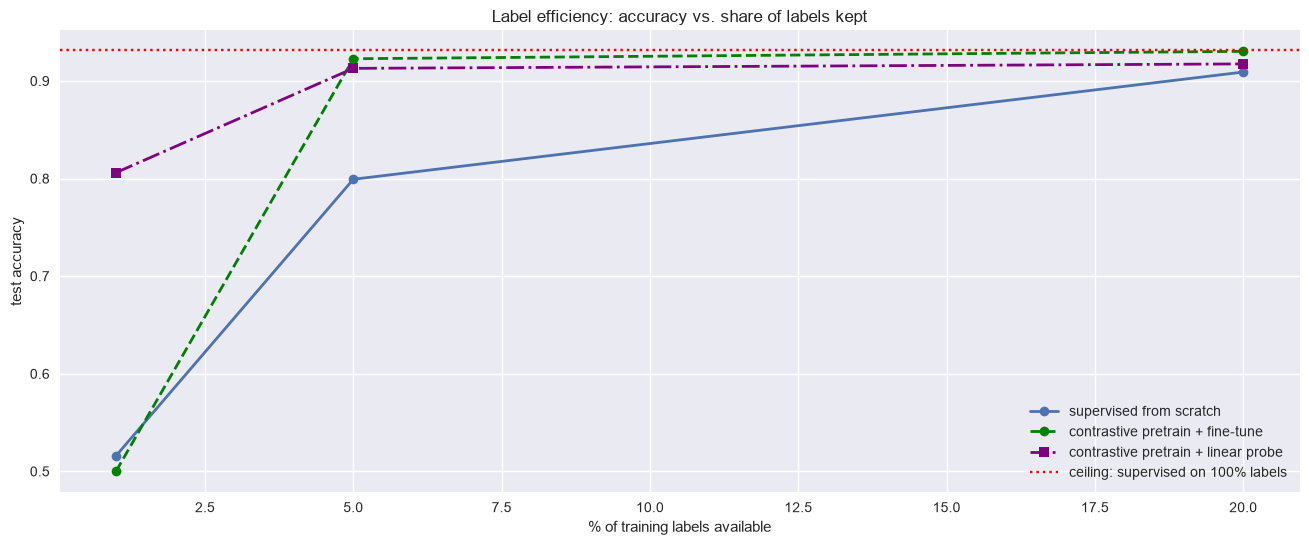

In [31]:
# how does the picture change as labels get scarcer or richer?
FRACTIONS = [0.01, 0.05, 0.20]

# the probe arm reuses features from the pristine pretrained encoder
with keras.device(DEVICE):
    feat_train = encoder_con.predict(X_train, batch_size=256, verbose=0)
    feat_test = encoder_con.predict(X_test, batch_size=256, verbose=0)

curve = {'scratch': [], 'fine-tune': [], 'probe': []}
for frac in FRACTIONS:
    m = make_labeled_split(y_train, frac, CFG.SEED)
    Xf, yf = X_train[m], y_train[m]
    ms = fit_classifier(Xf, yf, CFG.small_epochs, CFG.small_batch)
    curve['scratch'].append(test_accuracy(ms))
    enc = build_encoder(pooled=True)
    enc.set_weights(contrastive_weights)          # restart from the SAME pretraining
    mf = fit_classifier(Xf, yf, CFG.finetune_epochs, CFG.small_batch,
                        encoder=enc, lr=1e-4)
    curve['fine-tune'].append(test_accuracy(mf))
    clf = LogisticRegression(max_iter=2000).fit(feat_train[m], yf)
    curve['probe'].append(float(clf.score(feat_test, y_test)))
    print(f'{frac:.0%} labels ({m.sum()} series): '
          f'scratch {curve["scratch"][-1]:.3f}, '
          f'fine-tune {curve["fine-tune"][-1]:.3f}, '
          f'probe {curve["probe"][-1]:.3f}')

pct = [f * 100 for f in FRACTIONS]
plt.plot(pct, curve['scratch'], linewidth=2, marker='o',
         label='supervised from scratch')
plt.plot(pct, curve['fine-tune'], color='green', linestyle='--', linewidth=2,
         marker='o', label='contrastive pretrain + fine-tune')
plt.plot(pct, curve['probe'], color='purple', linestyle='-.', linewidth=2,
         marker='s', label='contrastive pretrain + linear probe')
plt.axhline(scores['supervised CNN (100% labels)'], color='red', linestyle=':',
            label='ceiling: supervised on 100% labels')
plt.title('Label efficiency: accuracy vs. share of labels kept')
plt.xlabel('% of training labels available')
plt.ylabel('test accuracy')
plt.legend()
plt.show()

The single-budget scoreboard answers "which method at 5%?"; this **label-efficiency curve** answers the strategic question - *when* is self-supervision worth the trouble, and in which form? We rerun three strategies at three label budgets (1%, 5%, 20%): supervised from scratch, fine-tuning from the contrastive pretraining, and the frozen-encoder linear probe. All arms use identical labeled subsets; both pretrained arms restart from the *same* `contrastive_weights` snapshot each time - pretraining is label-free, so one pretraining serves every budget, and only the cheap final stage repeats.

The shape of the three curves is the punchline of the notebook. At 5% and 20% of labels, the fine-tuned arm (green) rides within a point or so of the ceiling - 92.3% and 93.0% - while from-scratch training trails by twelve points at 5% (79.9%) and still two at 20% (90.9%). At 1% the picture inverts dramatically: from-scratch training *and fine-tuning* both collapse to the coin flip (51.6% and 50.0%) - yet the linear probe on the very same pretrained encoder reaches 80.6%, roughly what from-scratch training needs five times as many labels to achieve.

Behind the 1% surprise sits a rule worth internalizing: **the fewer labels you have, the fewer parameters you can afford to touch.** Thirty-six examples are too few to train even a fine-tuning run - ~100 gradient steps barely move the fresh softmax head, while every step of adaptation risks scrambling the pretrained features and the BatchNorm statistics. The 65-parameter logistic probe, by contrast, is perfectly happy. The practical decision rules that fall out: **below a few percent of labels**, freeze the encoder and probe; **in the middle band**, fine-tune - it is the difference between unusable and near-ceiling; **as labels grow past ~20%**, the from-scratch model closes in and the pretraining premium shrinks toward noise, at which point the extra pipeline may no longer pay. Map your own project onto this curve - how many labels, at what cost per label? - and it tells you whether this notebook's machinery belongs in your stack.

# Where to go from here

Everything in this notebook is the *simplest honest version* of its idea, and each has a heavily-engineered descendant in the literature worth knowing by name.

On the self-supervised side: our contrastive setup is a stripped-down cousin of **TS2Vec** (hierarchical contrasting at many time scales; the reference "universal" time series encoder) and **TS-TCC** (the origin of our weak/strong augmentation pairing, with a cross-view prediction task on top). **TF-C** adds a frequency-domain encoder and requires time- and frequency-views to agree - a natural next step for signals like FordA whose class information is spectral. Our masked autoencoder is the primitive form of **PatchTST** and **SimMTM** (subtler masking and reconstruction schemes on Transformer backbones) - and scaled to millions of series, masked pretraining is how time series **foundation models** (MOMENT, Chronos, TimesFM - see notebook m14) are built; "fine-tune a foundation model" is increasingly the strongest label-scarce baseline of all.

On the semi-supervised side: **CA-TCC** is the canonical marriage of both worlds - contrastive pretraining *plus* pseudo-label-aware fine-tuning; **FlexMatch** upgrades FixMatch's fixed confidence threshold to per-class adaptive ones; **Mean Teacher** replaces our discrete self-training rounds with a continuously-updated exponential-moving-average teacher.

And whatever you try first: keep the habits this notebook practiced. Hold out a real test set. Run the embarrassing baseline. Audit your pseudo-labels if you possibly can. And read any "SOTA" table - including our scoreboard above - as one seed's worth of evidence, not gospel.